Simulate Viral Dynamic Model

In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from google.colab import drive
import math
import matplotlib.ticker as ticker

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
vd_df = pd.read_excel('./ViralDynamicsData_Publication.xlsx')

In [ ]:
# Keep only treated individuals and sort for piecewise simulation
treated_df = vd_df[vd_df["treatment_cov"] == 1].copy()
treated_df = treated_df.sort_values(["ID", "time"])

In [ ]:
params_df_A1 = pd.read_csv("./estimatedIndividualParameters_A1.txt", sep=',')
params_df_A2 = pd.read_csv("./estimatedIndividualParameters_A2.txt", sep=',')
params_df_A3 = pd.read_csv("./estimatedIndividualParameters_A3.txt", sep=',')
params_df_A4T = pd.read_csv("./estimatedIndividualParameters_A4T.txt", sep=',')

In [ ]:

PK_CONSTANTS = {
   "A1": {"MolMass": 602.58, "Volume": 3690},
   "A2": {"MolMass": 442.32, "Volume": 30446.12},
   "A3": {"MolMass": 291.26, "Volume": 924.6},
   "A4T": {"MolMass": 531.2, "Volume": 1000000}
}

PD_PARAMS = {
   "Emax": 0.99,
   "Hill": 1,
   "c": 15,
   "k": 4,
   "F": 1_000_000
}

# Fixed PK Parameters
FIXED_PK = {
    "k12":22.525296,
    "k23":0.6,
    "kcl1":0.000864,
    "kcl2":9.6,
    "kcl3":6,
    "kcl4":1.0824,
    "k1pt":319.2,
    "k1tp":3.12,
    "k2pt":10.32,
    "k2tp":0.01296,
    "k3tp":0.036,
    "k3pt":1.08,
    "k34":6
}

In [ ]:

def viral_dynamic_model(t, y, target_cpt, params, dynamic_inputs):
  """
  Combined PK/PD and Viral Dynamics ODE system.
  """
  A1, A1T, A2, A2T, A3, A3T, A4T, T, R, E, I, V = y

  # Unpack dynamic input
  treatment = dynamic_inputs['treatment']

  # Unpack VD parameters
  beta = params['beta']
  pi = params['pi']
  rho = params['rho']
  phi = params['phi']
  delta = params['delta']
  m = params['m']
  tau = params['tau']
  IC50 = params['IC50']

  # --- PK Model ---
  ddt_A1 = FIXED_PK['k1tp']*A1T - (FIXED_PK['k1pt'] + FIXED_PK['k12'] + FIXED_PK['kcl1'])*A1

  ddt_A2 = FIXED_PK['k12']*A1 + FIXED_PK['k2tp']*A2T - (FIXED_PK['k2pt'] + FIXED_PK['kcl2'] + FIXED_PK['k23'])*A2

  ddt_A3 = FIXED_PK['k3tp']*A3T - (FIXED_PK['kcl3'] + FIXED_PK['k3pt'])*A3 + FIXED_PK['k23']*A2

  ddt_A1T = (FIXED_PK['k1pt']*A1 - FIXED_PK['k1tp']*A1T - FIXED_PK['k12']*A1T)

  ddt_A2T = (FIXED_PK['k2pt']*A2 + FIXED_PK['k12']*A1T - FIXED_PK['k23']*A2T - FIXED_PK['k2tp']*A2T)

  ddt_A3T = (-FIXED_PK['k3tp']*A3T + FIXED_PK['k23']*A2T + FIXED_PK['k3pt']*A3 - FIXED_PK['k34']*A3T)

  ddt_A4T = (FIXED_PK['k34']*A3T - FIXED_PK['kcl4']*A4T)

  # --- PD Effect (epsilon) ---
  # Calculate Concentration based on target compartment
  if target_cpt == "A1":
      Cc = A1 / (PK_CONSTANTS["A1"]["Volume"] * PK_CONSTANTS["A1"]["MolMass"])
  elif target_cpt == "A2":
      Cc = A2 / (PK_CONSTANTS["A2"]["Volume"] * PK_CONSTANTS["A2"]["MolMass"])
  elif target_cpt == "A3":
      Cc = A3 / (PK_CONSTANTS["A3"]["Volume"] * PK_CONSTANTS["A3"]["MolMass"])
  elif target_cpt == "A4T":
      Cc = A4T / (PK_CONSTANTS["A4T"]["Volume"] * PK_CONSTANTS["A4T"]["MolMass"])
  else:
      Cc = 0

  if treatment == 0:
      epsilon = 0
  else:
      # Prevent division by zero
      if Cc <= 0:
          epsilon = 0
      else:
          epsilon = PD_PARAMS['Emax'] * (Cc**PD_PARAMS['Hill']) / ((Cc**PD_PARAMS['Hill']) + (IC50**PD_PARAMS['Hill']))

  # --- Viral Dynamics ---
  eps = m if t > tau else 0

  ddt_T = -beta * T * V - phi * I * T + rho * R
  ddt_R = phi * I * T - rho * R
  ddt_E = beta * T * V - PD_PARAMS['k'] * E
  ddt_I = PD_PARAMS['k'] * E - delta * I - eps * I

  # Enforce that infected cells do not produce virus until there is at least 1
  if I >= 1:
      temp = pi * (1 - epsilon) * I - PD_PARAMS['c'] * V
  else:
      temp = -PD_PARAMS['c'] * V

  ddt_V = temp

  return [ddt_A1, ddt_A1T, ddt_A2, ddt_A2T, ddt_A3, ddt_A3T, ddt_A4T, ddt_T, ddt_R, ddt_E, ddt_I, ddt_V]

In [ ]:

def simulate_patient(patient_id, target_cpt, data_df, param_df):
  """
  Simulates the VD model for a specific patient and a specific target compartment.
  """
  # 1. Extract Individual VD Parameters
  p_row = param_df[param_df['id'] == patient_id].iloc[0]

  params = {
      'beta': 10 ** p_row['log10beta_mode'],
      'pi': 10 ** p_row['log10pi_mode'],
      'rho': 10 ** p_row['log10rho_mode'],
      'phi': 10 ** p_row['log10phi_mode'],
      'delta': p_row['delta_mode'],
      'm': p_row['m_mode'],
      'tau': p_row['tau_mode'],
      'tzero': p_row['tzero_mode'],
      'Vzero': p_row['Vzero_mode'],
      'IC50': p_row['IC50_mode']
  }

  # 2. Extract Patient Data/Events
  pt_data = data_df[data_df['ID'] == patient_id].sort_values(by='time').copy()

  # Initial Conditions (at t = -tzero)
  # y = [A1, A1T, A2, A2T, A3, A3T, A4T, T, R, E, I, V]
  y0 = [0, 0, 0, 0, 0, 0, 0, 1e7, 0, 0, 0, params['Vzero']]
  t_start = -params['tzero']

  t_out = []
  y_out = []

  current_time = t_start

  # Track the active PK/PD covariates
  first_record = pt_data.iloc[0]
  active_inputs = {
      'treatment': first_record['treatment']
  }

  # 3. Piecewise Integration over Data Events
  for idx, row in pt_data.iterrows():
      t_event = row['time']

      if t_event > current_time:
          t_eval = np.linspace(current_time, t_event, max(50, int((t_event - current_time) * 100)))

          sol = solve_ivp(
              fun=viral_dynamic_model,
              t_span=(current_time, t_event),
              y0=y0,
              t_eval=t_eval,
              args=(target_cpt, params, active_inputs),
              method='LSODA',
              max_step=0.1
          )

          t_out.append(sol.t)
          y_out.append(sol.y)

          y0 = sol.y[:, -1]
          current_time = t_event

      dose_mg = row['Amnt_mg']
      if pd.notna(dose_mg) and dose_mg > 0:
          y0[0] += dose_mg * PD_PARAMS['F']

      active_inputs['treatment'] = row['treatment']

  t_final = current_time + 10
  t_eval = np.linspace(current_time, t_final, 500)
  sol = solve_ivp(
      fun=viral_dynamic_model,
      t_span=(current_time, t_final),
      y0=y0,
      t_eval=t_eval,
      args=(target_cpt, params, active_inputs),
      method='LSODA'
  )
  t_out.append(sol.t)
  y_out.append(sol.y)

  t_sim = np.concatenate(t_out)
  y_sim = np.concatenate(y_out, axis=1)

  # Extract Viral Load and apply LLOQ logic
  V_sim = y_sim[11, :]
  V_sim = np.where(V_sim < 200, 100, V_sim) # Values < LLOQ get imputed to 100 copies/mL
  log10V_sim = np.log10(V_sim)

  return t_sim, log10V_sim

Fig 2c: Treatment

Starting targeted simulations for 6 treated patients...


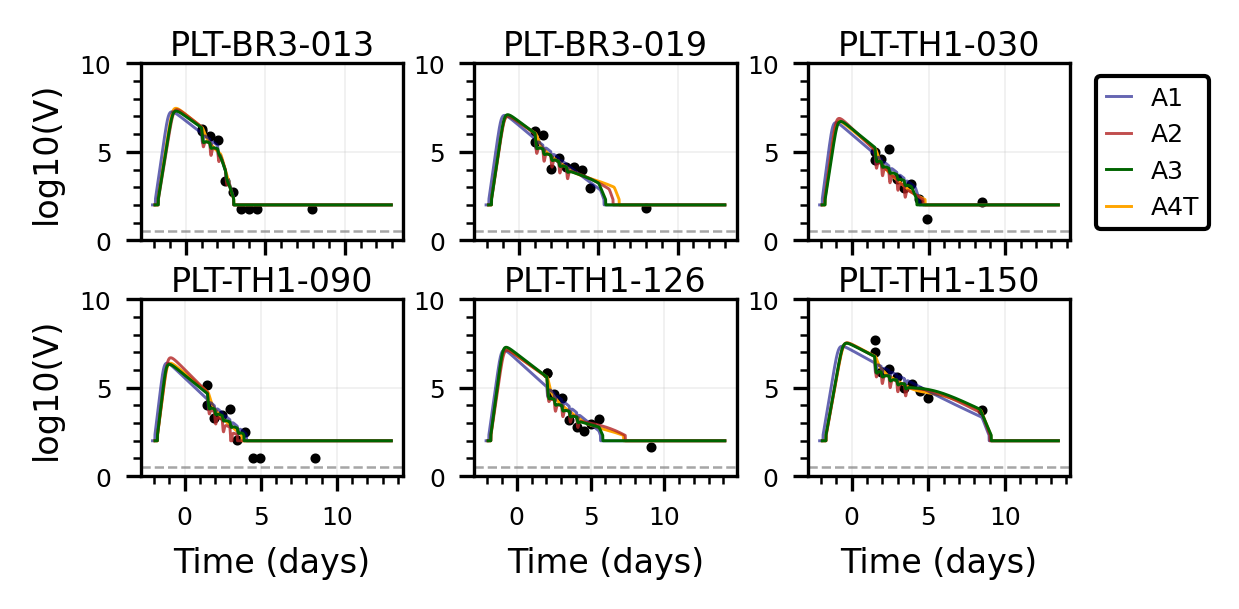

In [ ]:

TINY_SIZE = 6
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rcParams.update({
  'font.size': TINY_SIZE,
  'axes.labelsize': SMALL_SIZE,
  'xtick.labelsize': TINY_SIZE,
  'ytick.labelsize': TINY_SIZE,
  'axes.titlesize': TINY_SIZE,
  'figure.titlesize': SMALL_SIZE,
  'legend.fontsize': TINY_SIZE,
  'axes.titleweight': 'normal',
  'figure.titleweight': 'normal',
  'axes.labelweight': 'normal'
})

# Define patient subset
target_patients = [
  "PLT-BR3-013", "PLT-BR3-019", "PLT-TH1-030",
  "PLT-TH1-090", "PLT-TH1-126", "PLT-TH1-150"
]

rows, cols = 2, 3

print(f"Starting targeted simulations for {len(target_patients)} treated patients...")

fig, axes = plt.subplots(rows, cols, figsize=(4.0, 1.9), dpi=300)
axes = axes.flatten()

for i, PATIENT_ID in enumerate(target_patients):

  ax = axes[i]

  if PATIENT_ID not in treated_df['ID'].values:
      print(f"Warning: {PATIENT_ID} not found in dataset.")
      ax.set_title(f'{PATIENT_ID}', fontsize=SMALL_SIZE)
      ax.axis('off')
      continue

  # Simulations
  t_sim_A1, log10V_A1 = simulate_patient(PATIENT_ID, "A1", treated_df, params_df_A1)
  t_sim_A2, log10V_A2 = simulate_patient(PATIENT_ID, "A2", treated_df, params_df_A2)
  t_sim_A3, log10V_A3 = simulate_patient(PATIENT_ID, "A3", treated_df, params_df_A3)
  t_sim_A4T, log10V_A4T = simulate_patient(PATIENT_ID, "A4T", treated_df, params_df_A4T)

  # Observed data
  obs_data = treated_df[
      (treated_df['ID'] == PATIENT_ID) &
      (treated_df['y'].notna())
  ]

  ax.plot(t_sim_A1, log10V_A1, label='A1', linewidth=0.7, color='navy', alpha=0.6, zorder=10)
  ax.plot(t_sim_A2, log10V_A2, label='A2', linewidth=0.7, color='firebrick', alpha=0.8, zorder=10)
  ax.plot(t_sim_A3, log10V_A3, label='A3', linewidth=0.7, color='darkgreen', zorder=10)
  ax.plot(
    t_sim_A4T,
    log10V_A4T,
    label='A4T',
    linewidth=0.7,
    color='orange',
    zorder=9
  )

  ax.scatter(obs_data['time'], obs_data['y'], color='black', zorder=5, s=2)

  ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.6, alpha=0.7)

  ax.set_title(PATIENT_ID, fontsize=SMALL_SIZE, pad=2)

  ax.xaxis.set_minor_locator(ticker.MultipleLocator(2))

  if i >= 3:
      ax.set_xticks([0, 10, 20])
      ax.set_xticklabels(['0', '5', '10'])
      ax.set_xlabel('Time (days)', fontsize=SMALL_SIZE)
  else:
      ax.set_xticks([0, 10, 20])
      ax.tick_params(axis='x', labelbottom=False)

  if i % 3 == 0:
      ax.set_ylabel('log10(V)', fontsize=SMALL_SIZE)

  ax.set_ylim(0, 10)

  ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
  ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

  ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))

  ax.grid(True, alpha=0.2, linewidth=0.4)

  if i == 2:
      ax.legend(
          loc='upper left',
          bbox_to_anchor=(1.05, 1.0),
          framealpha=1.0,
          fontsize=TINY_SIZE,
          handlelength=1,
          edgecolor='black'
      )

plt.tight_layout(pad=0.4)

plt.show()

plt.rcdefaults()

Fig 2b: Control

Starting targeted simulations for 6 control arm patients...


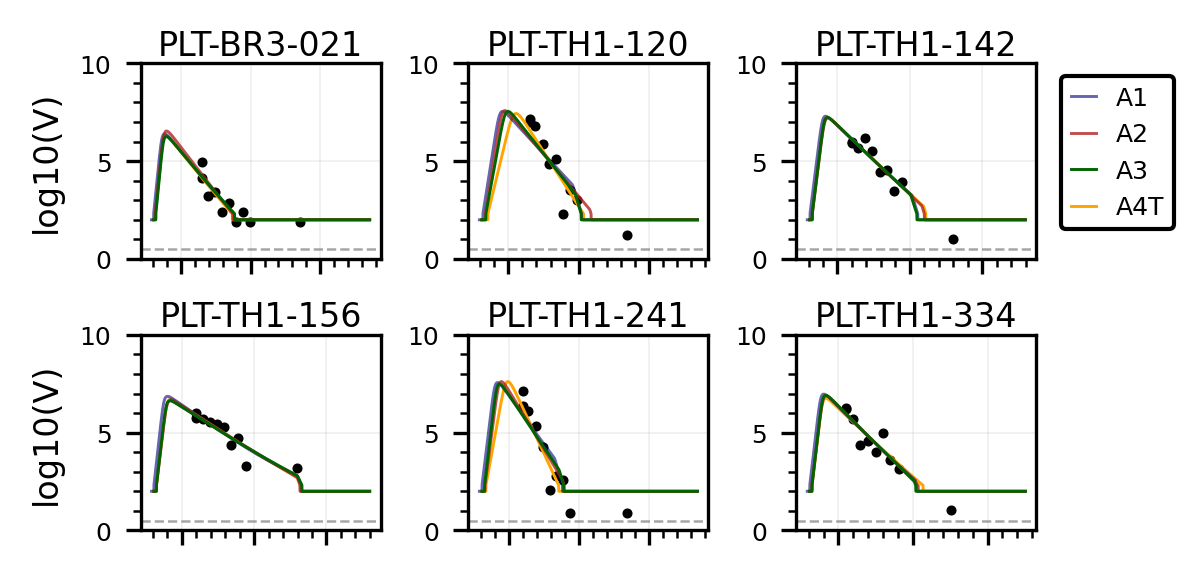

In [ ]:


TINY_SIZE = 6
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rcParams.update({
  'font.size': TINY_SIZE,
  'axes.labelsize': SMALL_SIZE,
  'xtick.labelsize': TINY_SIZE,
  'ytick.labelsize': TINY_SIZE,
  'axes.titlesize': TINY_SIZE,
  'figure.titlesize': SMALL_SIZE,
  'legend.fontsize': TINY_SIZE,
  'axes.titleweight': 'normal',
  'figure.titleweight': 'normal',
  'axes.labelweight': 'normal'
})

# 1. Filter dataset for Platcov Control Arm patients only
control_platcov_df = vd_df[(vd_df["treatment_cov"] == 0) & (vd_df["Study"] == "Platcov")].copy()
control_platcov_df = control_platcov_df.sort_values(["ID", "time"])

# 2. Define the exact subset of control patients to simulate
target_patients = [
  "PLT-BR3-021", "PLT-TH1-120", "PLT-TH1-142",
  "PLT-TH1-156", "PLT-TH1-241", "PLT-TH1-334"
]

rows, cols = 2, 3

print(f"Starting targeted simulations for {len(target_patients)} control arm patients...")


fig, axes = plt.subplots(rows, cols, figsize=(4.0, 1.9), dpi=300)

axes = axes.flatten()

for i, PATIENT_ID in enumerate(target_patients):

  ax = axes[i]

  if PATIENT_ID not in control_platcov_df['ID'].values:
      print(f"Warning: {PATIENT_ID} not found in control dataset.")
      ax.set_title(f'{PATIENT_ID}', fontsize=SMALL_SIZE)
      ax.axis('off')
      continue

  # Simulate
  t_sim_A1, log10V_A1 = simulate_patient(PATIENT_ID, "A1", control_platcov_df, params_df_A1)
  t_sim_A2, log10V_A2 = simulate_patient(PATIENT_ID, "A2", control_platcov_df, params_df_A2)
  t_sim_A3, log10V_A3 = simulate_patient(PATIENT_ID, "A3", control_platcov_df, params_df_A3)
  t_sim_A4T, log10V_A4T = simulate_patient(PATIENT_ID, "A4T", control_platcov_df, params_df_A4T)

  obs_data = control_platcov_df[
      (control_platcov_df['ID'] == PATIENT_ID) &
      (control_platcov_df['y'].notna())
  ]

  ax.plot(t_sim_A1, log10V_A1, label='A1', linewidth=0.7, color='navy', alpha=0.6, zorder=10)
  ax.plot(t_sim_A2, log10V_A2, label='A2', linewidth=0.7, color='firebrick', alpha=0.8, zorder=10)
  ax.plot(t_sim_A3, log10V_A3, label='A3', linewidth=0.7, color='darkgreen', zorder=10)
  ax.plot(
      t_sim_A4T,
      log10V_A4T,
      label='A4T',
      linewidth=0.7,
      color='orange',
      zorder=9
  )

  ax.scatter(obs_data['time'], obs_data['y'], color='black', zorder=5, s=2)

  ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.6, alpha=0.7)

  ax.set_title(PATIENT_ID, fontsize=SMALL_SIZE, pad=2)

  ax.tick_params(axis='x', labelbottom=False)

  if i % 3 == 0:
      ax.set_ylabel('log10(V)', fontsize=SMALL_SIZE)

  ax.set_ylim(0, 10)

  ax.grid(True, alpha=0.2, linewidth=0.4)

  if i == 2:
      ax.legend(
          loc='upper left',
          bbox_to_anchor=(1.05, 1.0),
          framealpha=1.0,
          fontsize=TINY_SIZE,
          handlelength=1,
          edgecolor='black'
      )

  ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
  ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))

  ax.xaxis.set_major_locator(ticker.MultipleLocator(10))

  ax.xaxis.set_minor_locator(ticker.MultipleLocator(2))

plt.tight_layout()

plt.show()

plt.rcdefaults()

Treatment arm Supplemental Figure

Starting simulations for 67 patients on a single page...


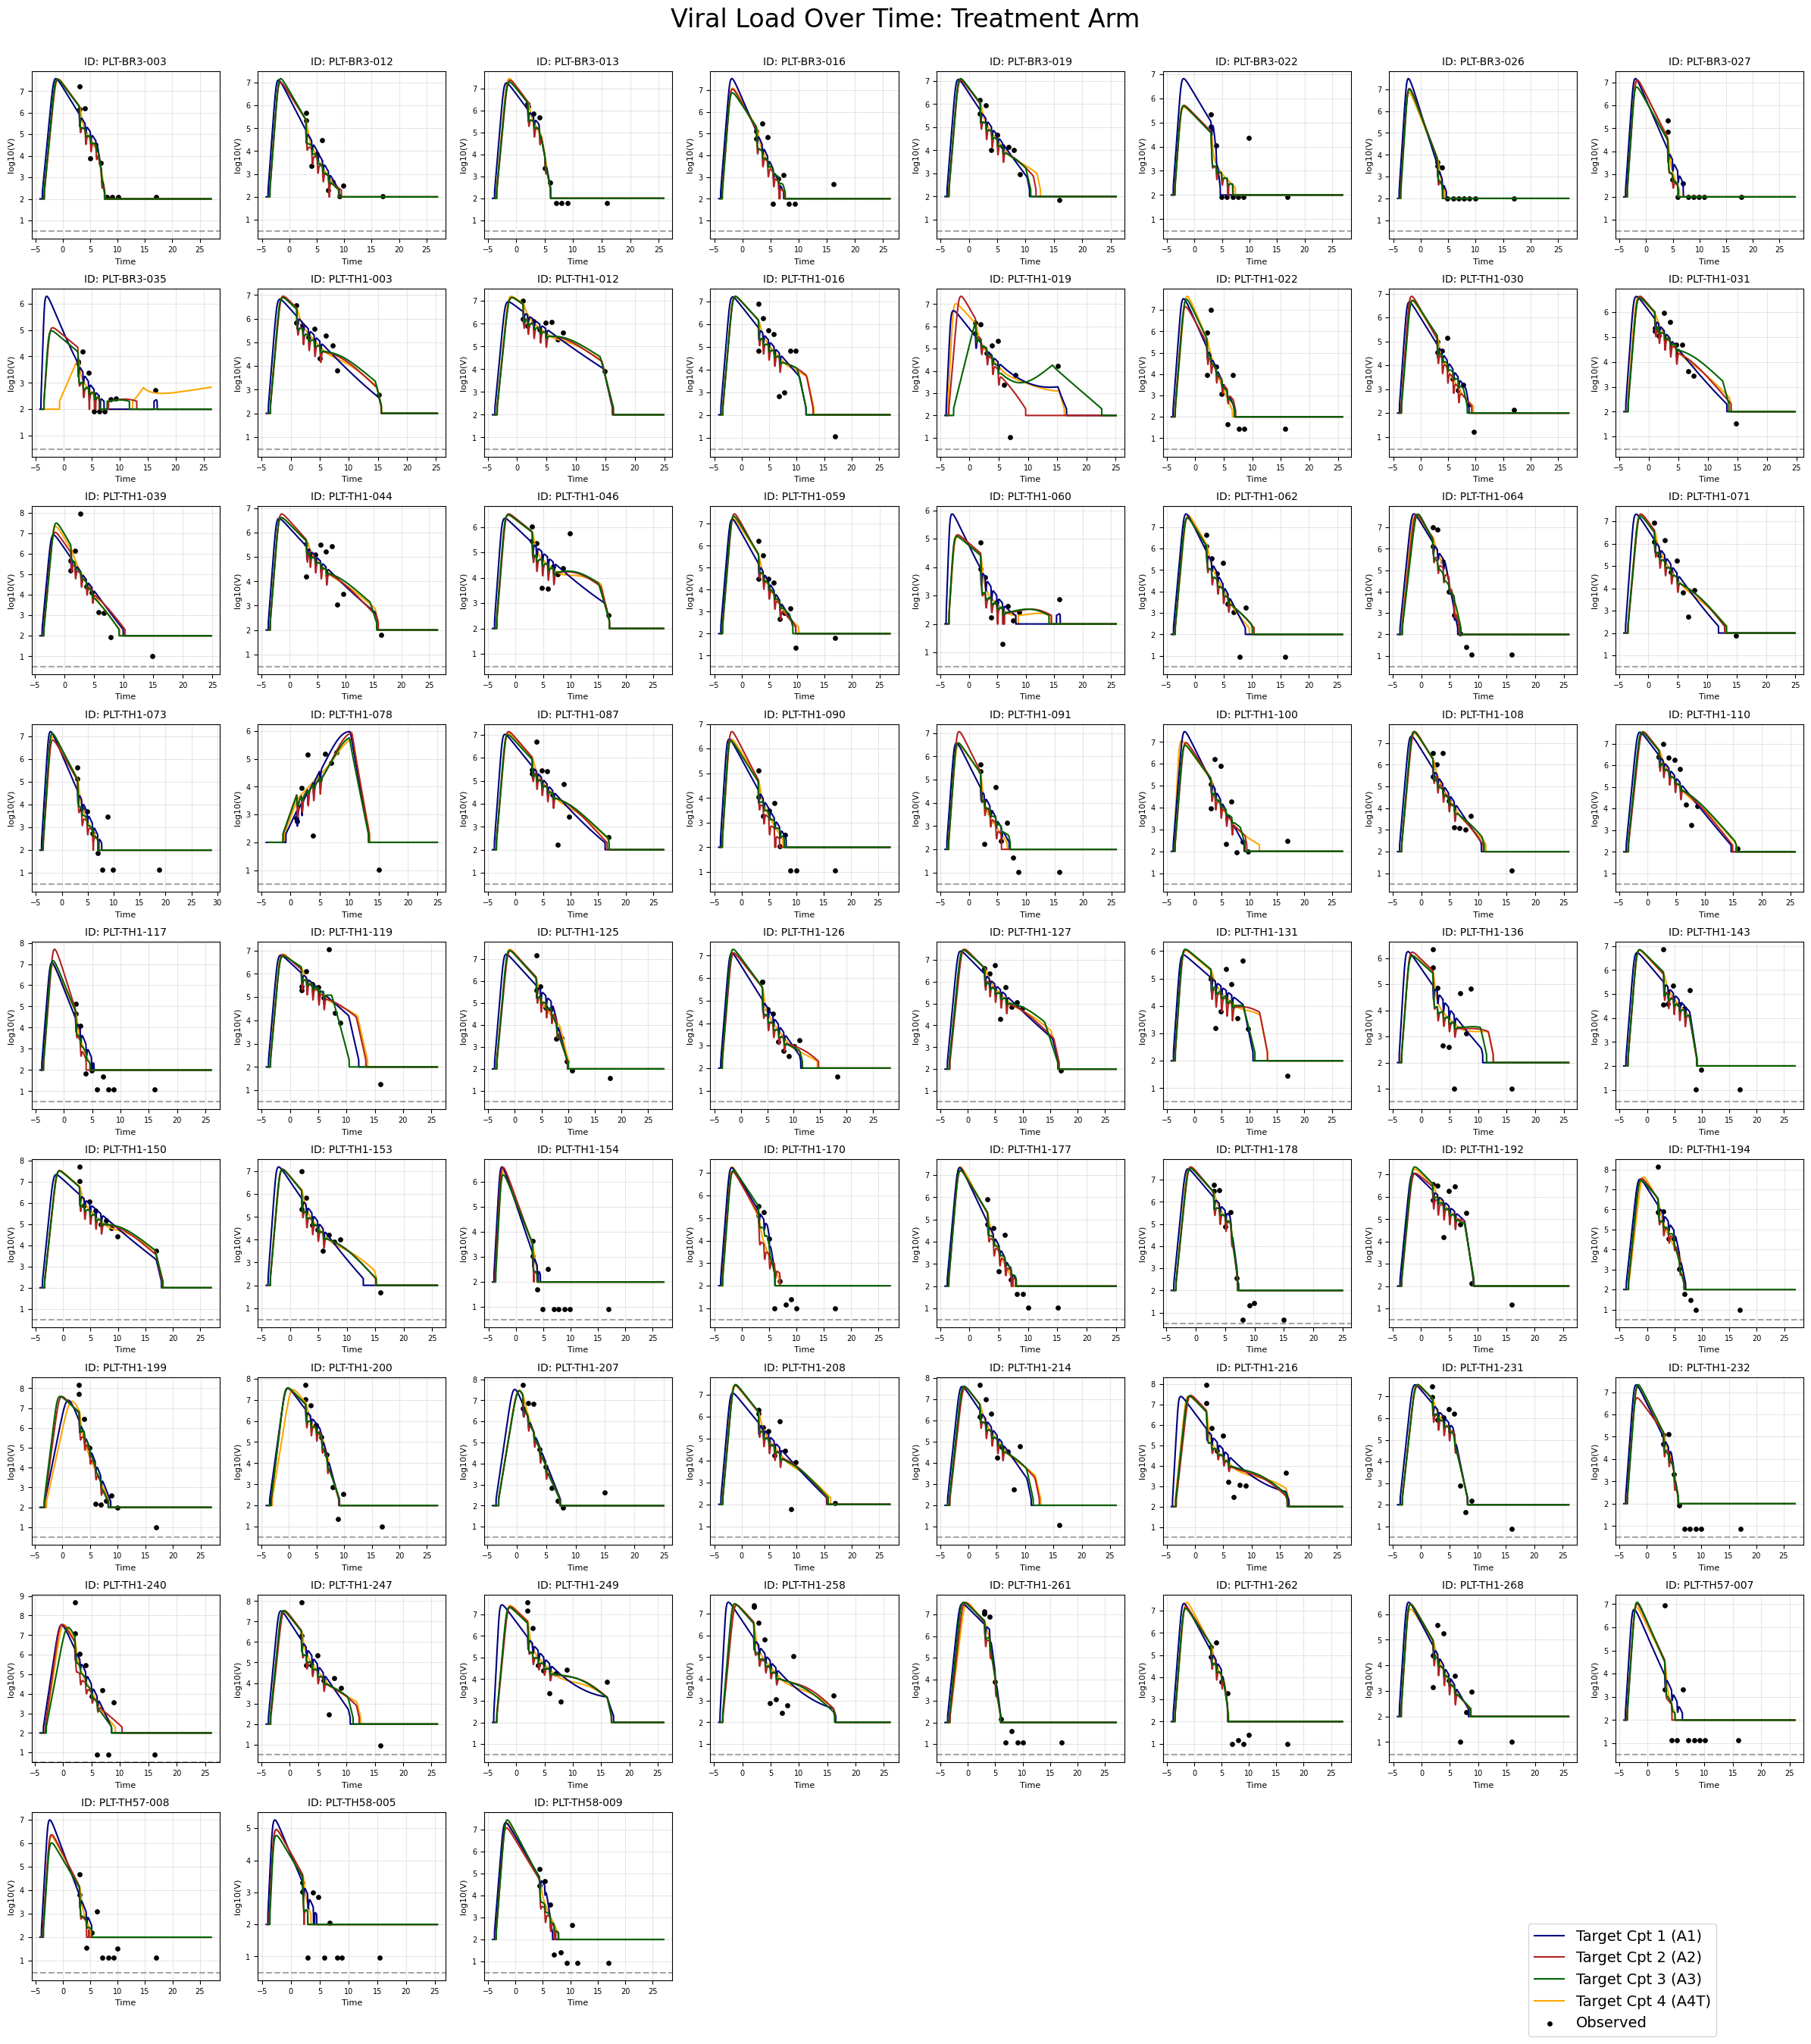

In [ ]:

unique_patient_ids = treated_df['ID'].unique()
num_patients = len(unique_patient_ids)

rows = 9
cols = 8

print(f"Starting simulations for {num_patients} patients on a single page...")


fig, axes = plt.subplots(rows, cols, figsize=(24, 28))
axes = axes.flatten()

for i, PATIENT_ID in enumerate(unique_patient_ids):
    ax = axes[i]

    # 2. Simulate for each compartment assumption
    t_sim_A1, log10V_A1 = simulate_patient(PATIENT_ID, "A1", treated_df, params_df_A1)
    t_sim_A2, log10V_A2 = simulate_patient(PATIENT_ID, "A2", treated_df, params_df_A2)
    t_sim_A3, log10V_A3 = simulate_patient(PATIENT_ID, "A3", treated_df, params_df_A3)
    t_sim_A4T, log10V_A4T = simulate_patient(PATIENT_ID, "A4T", treated_df, params_df_A4T)

    obs_data = treated_df[(treated_df['ID'] == PATIENT_ID) & (treated_df['y'].notna())]

    # 3. Plotting
    ax.plot(t_sim_A1, log10V_A1, label='Target Cpt 1 (A1)', linewidth=1.5, color='navy', zorder=10)
    ax.plot(t_sim_A2, log10V_A2, label='Target Cpt 2 (A2)', linewidth=1.5, color='firebrick', zorder=10)
    ax.plot(t_sim_A3, log10V_A3, label='Target Cpt 3 (A3)', linewidth=1.5, color='darkgreen', zorder=10)
    ax.plot(t_sim_A4T, log10V_A4T, label='Target Cpt 4 (A4T)', linewidth=1.5, color='orange', zorder=9)
    ax.scatter(obs_data['time'], obs_data['y'], color='black', label='Observed', zorder=5, s=15)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)

    ax.set_title(f'ID: {PATIENT_ID}', fontsize=10)
    ax.set_xlabel('Time', fontsize=8)
    ax.set_ylabel('log10(V)', fontsize=8)
    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.grid(True, alpha=0.3)

for j in range(num_patients, len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=14, bbox_to_anchor=(0.95, 0.03))

fig.suptitle('Viral Load Over Time: Treatment Arm', fontsize=24, y=0.99)

plt.tight_layout()
plt.subplots_adjust(top=0.96, bottom=0.06)

plt.show()
plt.close(fig)

Control arm Supplemental Figure

Starting Control Arm simulations across 95 Platcov patients...
Generating 2 pages...


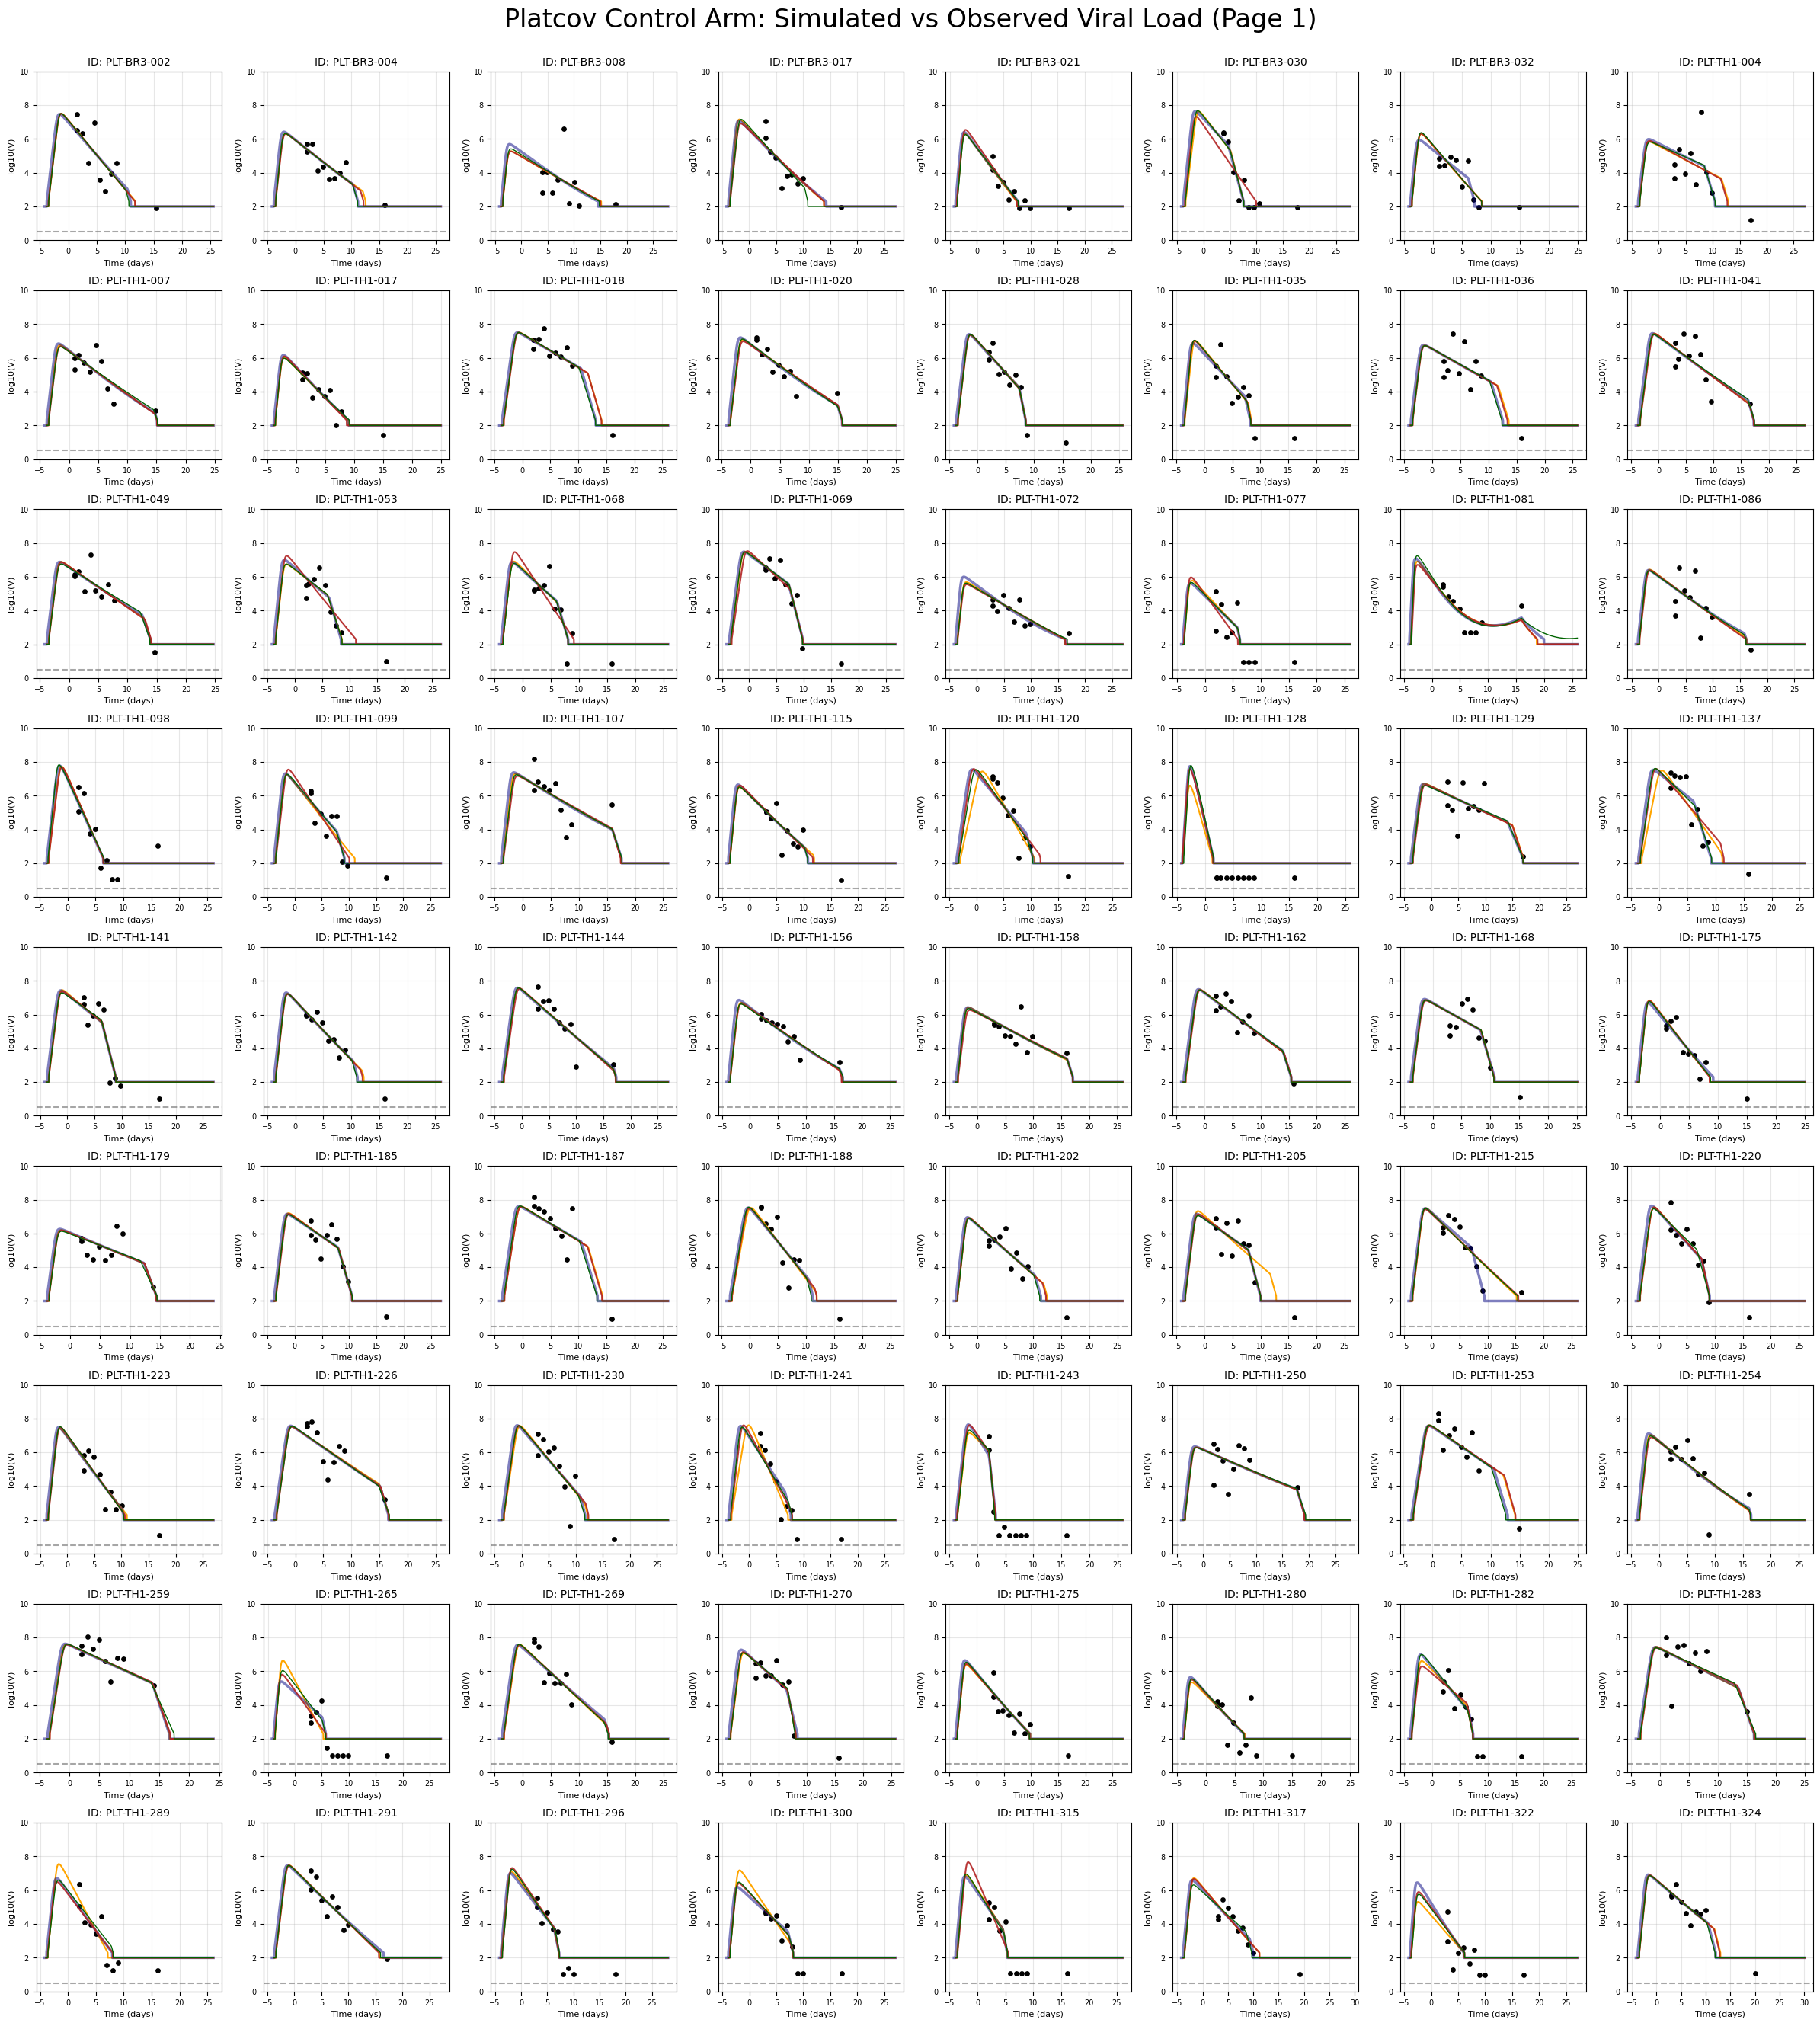

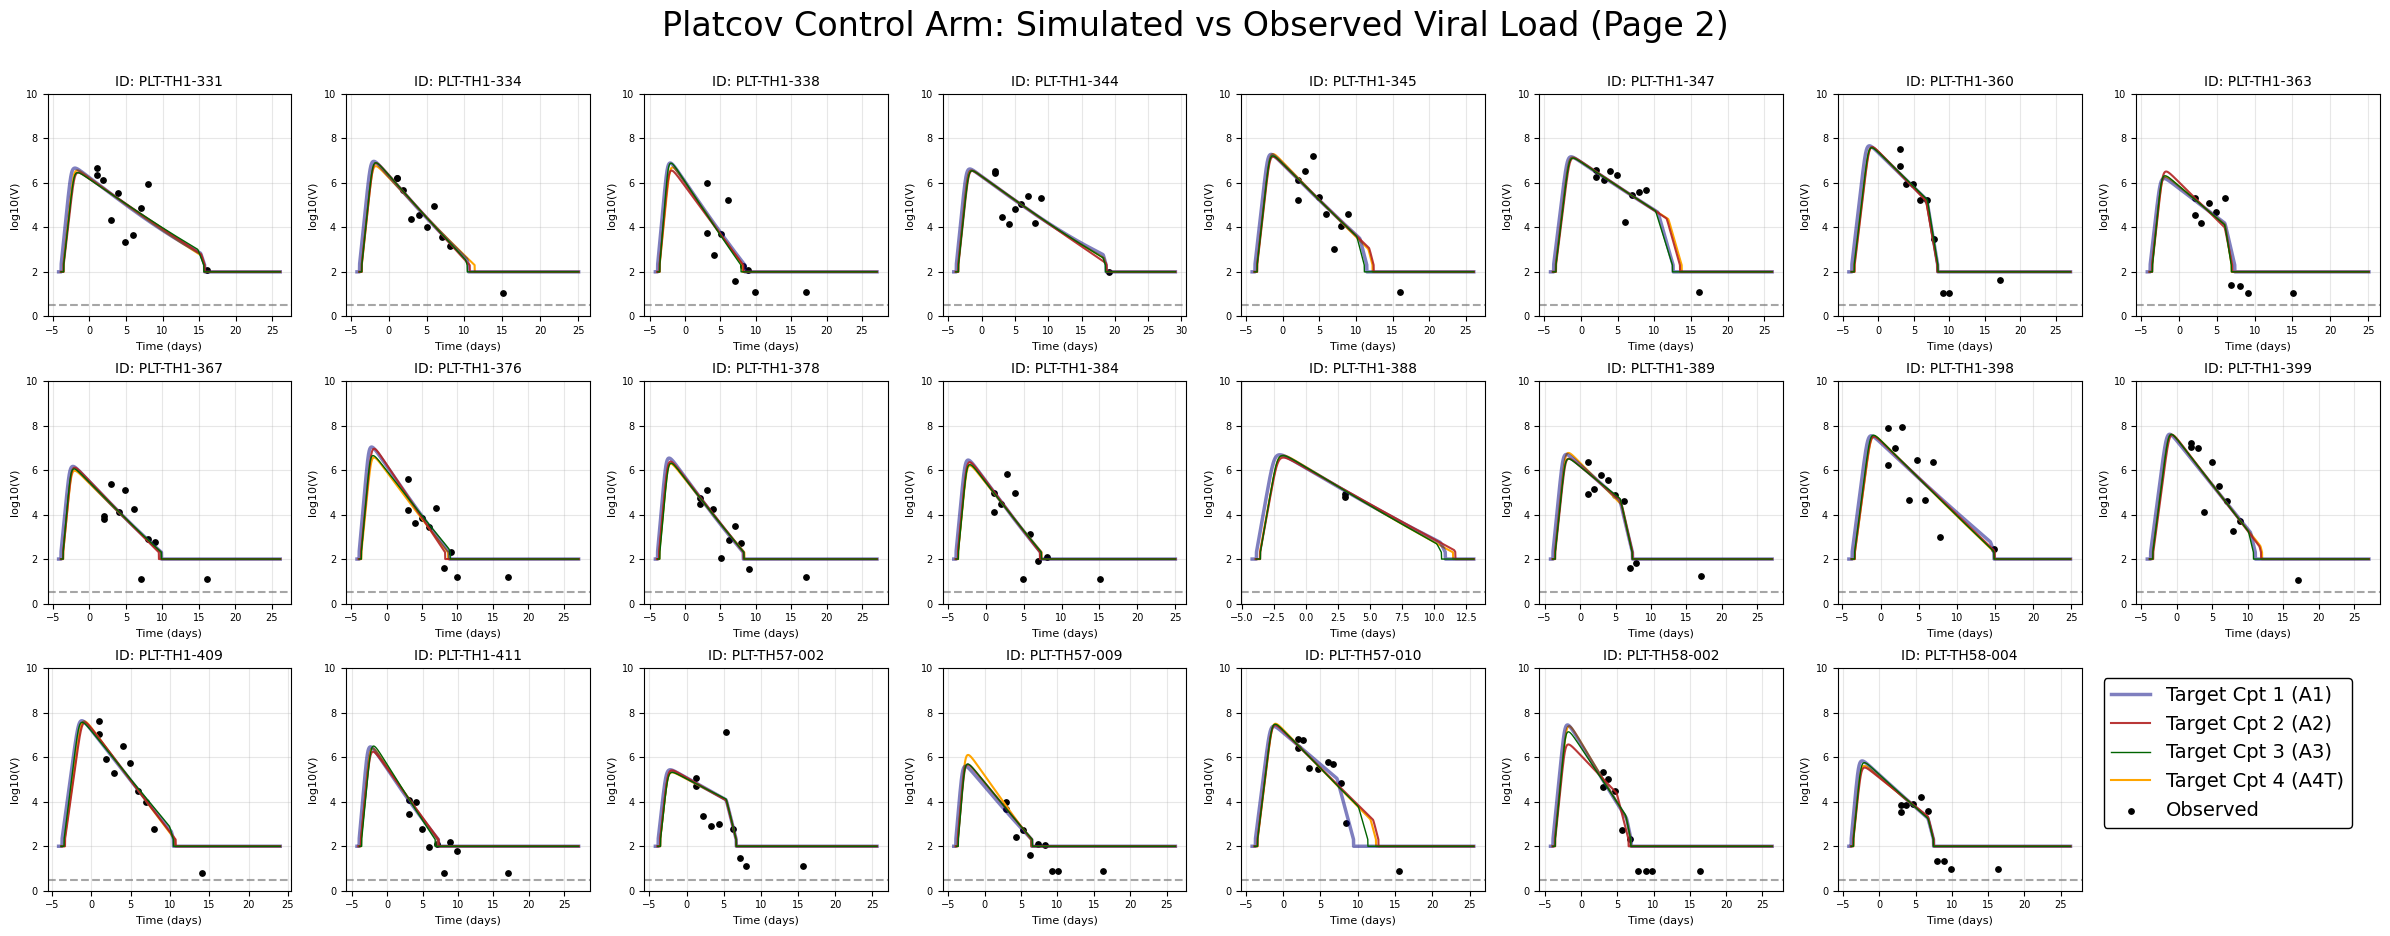

In [ ]:

control_platcov_df = vd_df[(vd_df["treatment_cov"] == 0) & (vd_df["Study"] == "Platcov")].copy()
control_platcov_df = control_platcov_df.sort_values(["ID", "time"])

# 2. Extract ALL unique patient IDs
unique_control_ids = control_platcov_df['ID'].unique()
num_patients = len(unique_control_ids)

rows = 9
cols = 8
plots_per_fig = rows * cols

print(f"Starting Control Arm simulations across {num_patients} Platcov patients...")
print(f"Generating {num_patients // plots_per_fig + 1} pages...")

for i, PATIENT_ID in enumerate(unique_control_ids):

    if i % plots_per_fig == 0:
        page_num = (i // plots_per_fig) + 1
        fig, axes = plt.subplots(rows, cols, figsize=(24, 28))
        fig.suptitle(f"Platcov Control Arm: Simulated vs Observed Viral Load (Page {page_num})", fontsize=24, y=0.99)
        axes = axes.flatten()

    ax = axes[i % plots_per_fig]

    t_sim_A1, log10V_A1 = simulate_patient(PATIENT_ID, "A1", control_platcov_df, params_df_A1)
    t_sim_A2, log10V_A2 = simulate_patient(PATIENT_ID, "A2", control_platcov_df, params_df_A2)
    t_sim_A3, log10V_A3 = simulate_patient(PATIENT_ID, "A3", control_platcov_df, params_df_A3)
    t_sim_A4T, log10V_A4T = simulate_patient(PATIENT_ID, "A4T", control_platcov_df, params_df_A4T)

    obs_data = control_platcov_df[(control_platcov_df['ID'] == PATIENT_ID) & (control_platcov_df['y'].notna())]

    ax.plot(t_sim_A1, log10V_A1, label='Target Cpt 1 (A1)', linewidth=2.5, color='navy', alpha=0.5, zorder=10)
    ax.plot(t_sim_A2, log10V_A2, label='Target Cpt 2 (A2)', linewidth=1.5, color='firebrick', alpha=0.9, zorder=10)
    ax.plot(t_sim_A3, log10V_A3, label='Target Cpt 3 (A3)', linewidth=1.0, color='darkgreen', zorder=10)
    ax.plot(t_sim_A4T, log10V_A4T, label='Target Cpt 4 (A4T)', linewidth=1.5, color='orange', zorder=9)

    ax.scatter(obs_data['time'], obs_data['y'], color='black', label='Observed', zorder=5, s=15)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)

    ax.set_title(f'ID: {PATIENT_ID}', fontsize=10)
    ax.set_xlabel('Time (days)', fontsize=8)
    ax.set_ylabel('log10(V)', fontsize=8)
    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.set_ylim(0, 10)
    ax.grid(True, alpha=0.3)

    if (i + 1) % plots_per_fig == 0 or (i + 1) == num_patients:

        for j in range((i % plots_per_fig) + 1, plots_per_fig):
            axes[j].set_visible(False)

        if (i + 1) == num_patients:
            handles, labels = ax.get_legend_handles_labels()
            leg = ax.legend(
                handles,
                labels,
                loc='upper left',
                bbox_to_anchor=(1.05, 1.0),
                fontsize=14,
                frameon=True,
                framealpha=1.0,
                edgecolor='black'
            )
            leg.set_in_layout(False)

        plt.tight_layout()
        plt.subplots_adjust(top=0.96, bottom=0.06)

        plt.show()

        plt.close(fig)